# 🌸 Iris Flower Classification

### Oasis Infobyte — Data Science Internship
### Task 1: Iris Flower Classification

---

## 📌 Project Overview

This project develops machine learning classification models to
identify the species of an iris flower based on its physical
measurements.

The Iris dataset contains four numerical measurements:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The target variable contains three flower species:

- Setosa
- Versicolor
- Virginica

---

## 🎯 Objective

The primary objective is to build, evaluate, and compare multiple
machine learning classification algorithms and identify the
best-performing model for predicting iris flower species.

---

## 📊 Executive Summary

The Iris dataset was analyzed using Exploratory Data Analysis (EDA)
and data visualization techniques to understand feature
distributions and relationships between flower species.

Three classification algorithms were trained and compared:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Random Forest

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

Petal length and petal width were identified as particularly
discriminative features for distinguishing the Iris species.

Based on the evaluation results, **Logistic Regression was selected
as the best-performing model**, achieving an **F1-Score of 0.9333**.

---

## 📂 Dataset Information

The Iris dataset is obtained directly from the
`sklearn.datasets` module, so no external dataset download is
required.

### Dataset Characteristics

- **Total Samples:** 150
- **Features:** 4
- **Target Classes:** 3
- **Missing Values:** None

### Features

| Feature | Description |
|---|---|
| Sepal Length | Length of the sepal |
| Sepal Width | Width of the sepal |
| Petal Length | Length of the petal |
| Petal Width | Width of the petal |

### Target Classes

- Setosa
- Versicolor
- Virginica

---

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

---

## 🤖 Machine Learning Models

The following classification algorithms are implemented:

### 1. Logistic Regression

A linear classification algorithm used as a strong baseline
model.

### 2. K-Nearest Neighbors (KNN)

A distance-based classification algorithm that predicts the class
of a sample based on its nearest neighbors.

### 3. Random Forest

An ensemble learning algorithm that combines multiple decision
trees to improve classification performance.

---

## 📈 Evaluation Metrics

The models are evaluated using:

- **Accuracy:** Overall percentage of correctly classified samples.
- **Precision:** Proportion of predicted positive samples that are
  actually correct.
- **Recall:** Proportion of actual samples correctly identified.
- **F1-Score:** Harmonic mean of precision and recall.
- **Confusion Matrix:** Shows correct and incorrect predictions for
  each species.

---

## 🔬 Machine Learning Workflow

1. Dataset Loading
2. Exploratory Data Analysis
3. Data Quality Check
4. Statistical Analysis
5. Data Visualization
6. Feature Analysis
7. Train-Test Split
8. Feature Scaling
9. Model Training
10. Model Evaluation
11. Model Comparison
12. Best Model Selection
13. Sample Prediction
14. Conclusion

## 1. Project Objective

The objective of this project is to develop machine learning
classification models that can predict the species of an iris flower
based on four physical measurements:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The three target species are:

1. Setosa
2. Versicolor
3. Virginica

The project includes exploratory data analysis, visualization,
feature analysis, model training, evaluation, comparison, and
selection of the best-performing classifier.

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Suppress unnecessary warnings
warnings.filterwarnings("ignore")

# Visualization settings
sns.set_theme(style="whitegrid")

print("All required libraries imported successfully.")

All required libraries imported successfully.


## 2. Load Dataset

The Iris dataset is available directly through Scikit-learn,
so no external download is required.

The dataset contains 150 observations with four numerical
features and three target classes.

In [2]:
# ============================================================
# LOAD IRIS DATASET
# ============================================================

iris = load_iris()

print("Dataset loaded successfully.")
print(f"Number of samples: {iris.data.shape[0]}")
print(f"Number of features: {iris.data.shape[1]}")

Dataset loaded successfully.
Number of samples: 150
Number of features: 4


In [3]:
# Display dataset information

print("Feature Names:")
print(iris.feature_names)

print("\nTarget Names:")
print(iris.target_names)

print("\nDataset Shape:")
print(iris.data.shape)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']

Dataset Shape:
(150, 4)


In [4]:
# ============================================================
# CREATE DATAFRAME
# ============================================================

feature_names = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

df = pd.DataFrame(
    iris.data,
    columns=feature_names
)

df["target"] = iris.target

df["species"] = df["target"].map(
    {
        0: "Setosa",
        1: "Versicolor",
        2: "Virginica"
    }
)

print("DataFrame created successfully.")

df.head()

DataFrame created successfully.


,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


# 🔎 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the
structure, quality, distribution, and relationships within the
dataset before applying machine learning algorithms.

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 150
Number of columns: 6


In [6]:
print("Data Types:\n")
print(df.dtypes)

Data Types:

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
target            int32
species          object
dtype: object


In [7]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
species         0
dtype: int64


### Missing Value Observation

The dataset contains no missing values, so no missing-value
imputation is required.

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1


In [9]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [10]:
# ============================================================
# DATA QUALITY SUMMARY
# ============================================================

quality_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

quality_summary

,Column,Data Type,Missing Values,Unique Values
0,sepal_length,float64,0,35
1,sepal_width,float64,0,23
2,petal_length,float64,0,43
3,petal_width,float64,0,22
4,target,int32,0,3
5,species,object,0,3


## 4. Target Class Distribution

Before training the models, we check the distribution of the
three target classes.

In [11]:
# ============================================================
# CLASS DISTRIBUTION
# ============================================================

class_distribution = (
    df["species"]
    .value_counts()
    .rename_axis("Species")
    .reset_index(name="Count")
)

class_distribution

,Species,Count
0,Setosa,50
1,Versicolor,50
2,Virginica,50


In [12]:
# ==========================================
# Global Visualization Theme
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Dark theme
plt.style.use("dark_background")

# Global figure settings
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["figure.facecolor"] = "#1E1E1E"

# Axes settings
plt.rcParams["axes.facecolor"] = "#1E1E1E"
plt.rcParams["axes.edgecolor"] = "#FFFFFF"
plt.rcParams["axes.labelcolor"] = "#FFFFFF"
plt.rcParams["axes.titlecolor"] = "#FFFFFF"

# Text
plt.rcParams["text.color"] = "#FFFFFF"

# Ticks
plt.rcParams["xtick.color"] = "#FFFFFF"
plt.rcParams["ytick.color"] = "#FFFFFF"

# Grid
plt.rcParams["grid.color"] = "#444444"
plt.rcParams["grid.alpha"] = 0.5

# Seaborn theme
sns.set_theme(
    style="darkgrid",
    context="notebook",
    palette="viridis"
)

print("Dark visualization theme applied successfully.")

Dark visualization theme applied successfully.


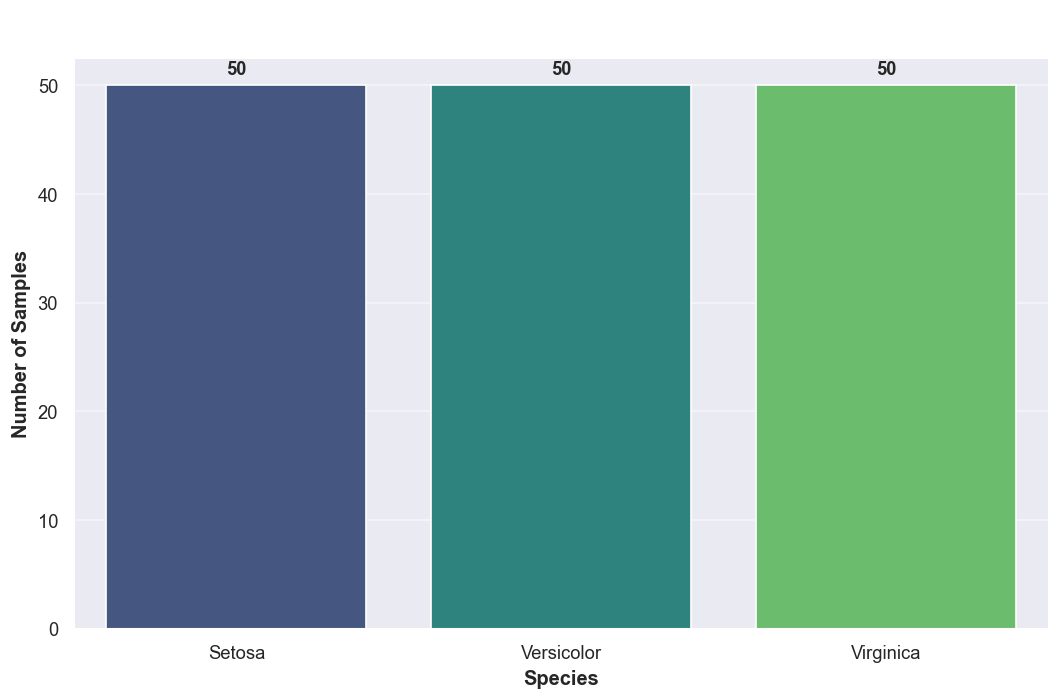

In [13]:
# ============================================================
# IRIS SPECIES DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df,
    x="species",
    hue="species",
    palette="viridis",
    legend=False
)

plt.title(
    "Distribution of Iris Species",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Species",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Samples",
    fontsize=12,
    fontweight="bold"
)

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=11,
        fontweight="bold",
        padding=4
    )

plt.tight_layout()

plt.savefig(
    "../images/species_distribution.png",
    bbox_inches="tight"
)

plt.show()

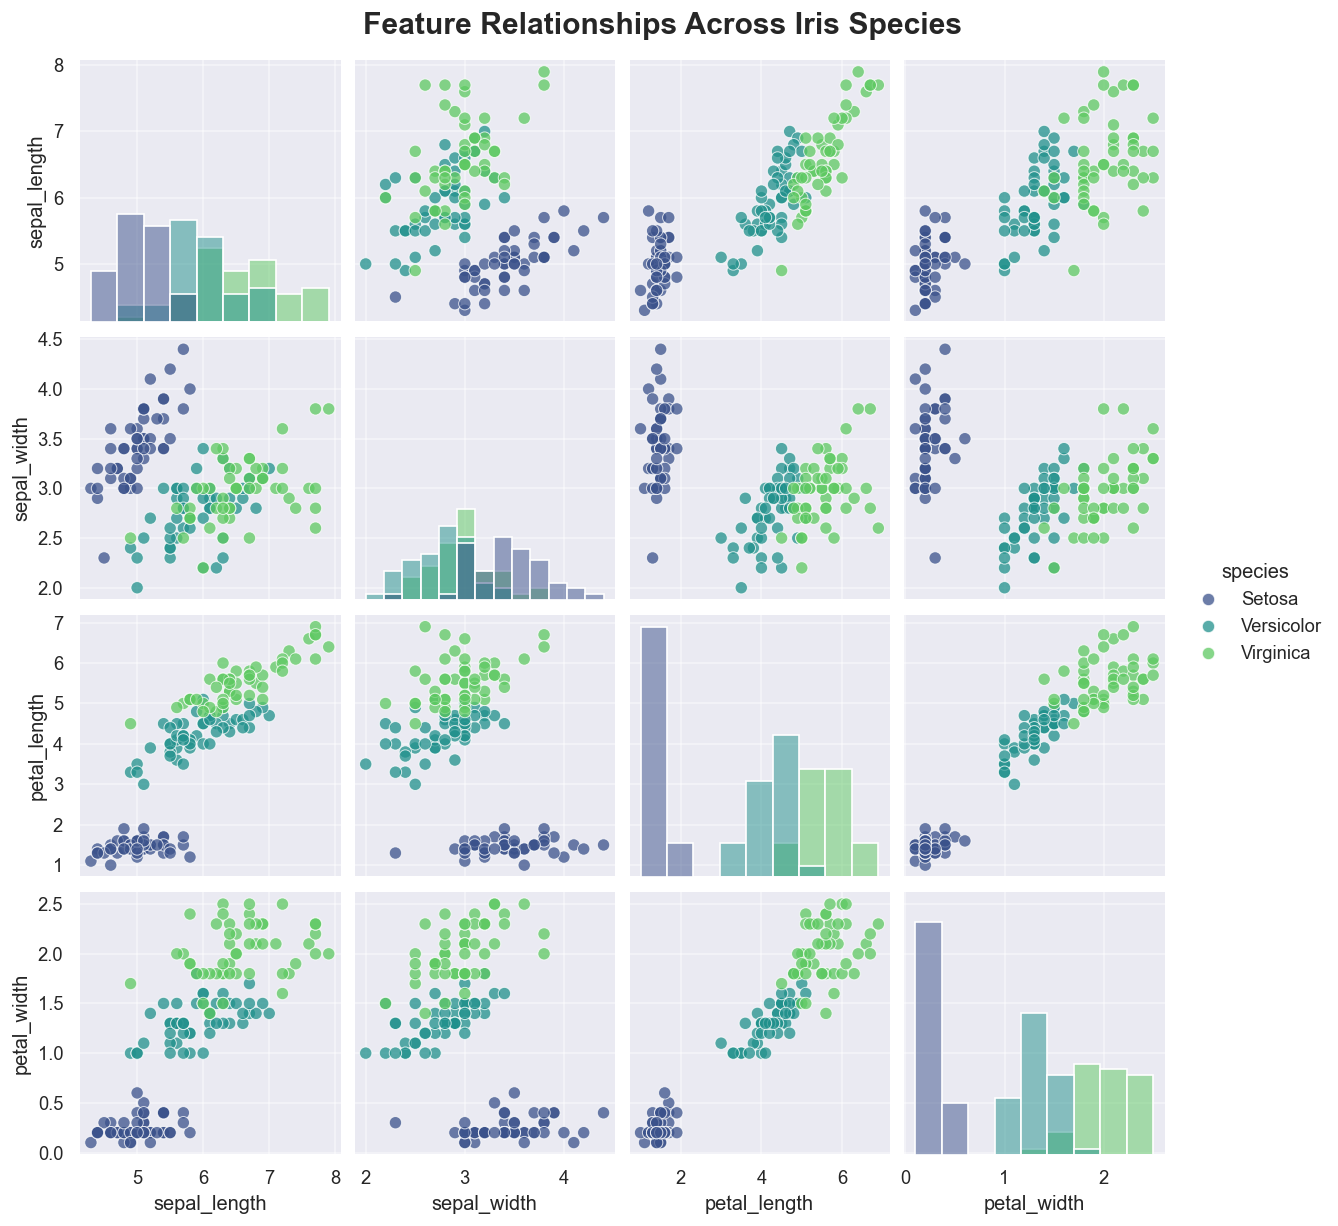

In [14]:
# ============================================================
# FEATURE RELATIONSHIPS BY SPECIES
# ============================================================

pairplot = sns.pairplot(
    df,
    vars=feature_names,
    hue="species",
    palette="viridis",
    diag_kind="hist",
    height=2.5,
    plot_kws={
        "alpha": 0.75,
        "s": 55
    }
)

pairplot.fig.suptitle(
    "Feature Relationships Across Iris Species",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

pairplot.savefig(
    "../images/iris_pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 🔍 Pairplot Interpretation

The pairplot shows the relationships between the four numerical
features across the three iris species.

Petal length and petal width provide particularly strong separation
between the species. Setosa forms a clearly distinct cluster, while
Versicolor and Virginica show some overlap.

This indicates that petal-related measurements are highly useful
features for classification.

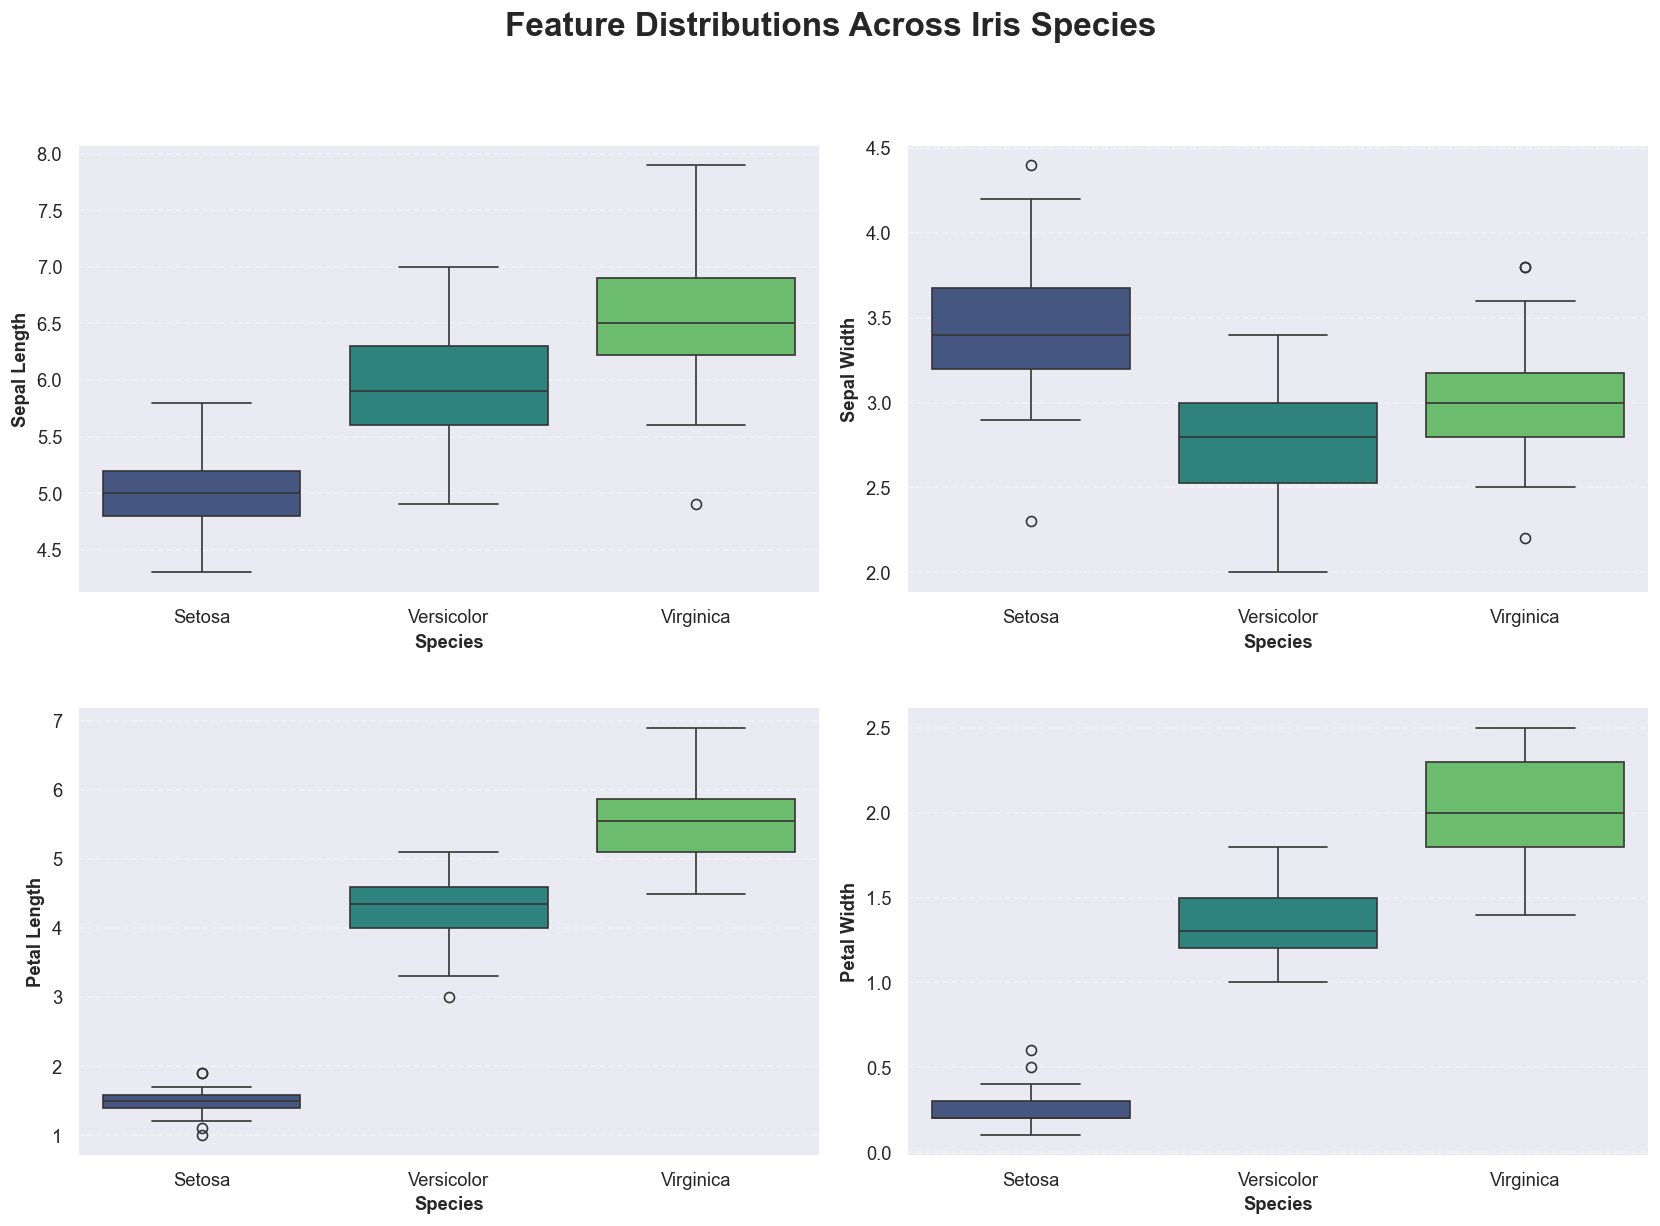

In [15]:
# ============================================================
# FEATURE DISTRIBUTION BY SPECIES
# ============================================================

features = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

for ax, feature in zip(
    axes.flatten(),
    feature_names
):

    sns.boxplot(
        data=df,
        x="species",
        y=feature,
        hue="species",
        palette="viridis",
        legend=False,
        ax=ax
    )

    ax.set_title(
        f"{feature.replace('_', ' ').title()} Distribution",
        fontsize=15,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel(
        "Species",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_ylabel(
        feature.replace("_", " ").title(),
        fontsize=11,
        fontweight="bold"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

fig.suptitle(
    "Feature Distributions Across Iris Species",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "../images/iris_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Boxplot Interpretation

The boxplots demonstrate differences in feature distributions
across the three species.

Petal length and petal width show stronger separation between
species than sepal measurements, making them particularly useful
for classification.

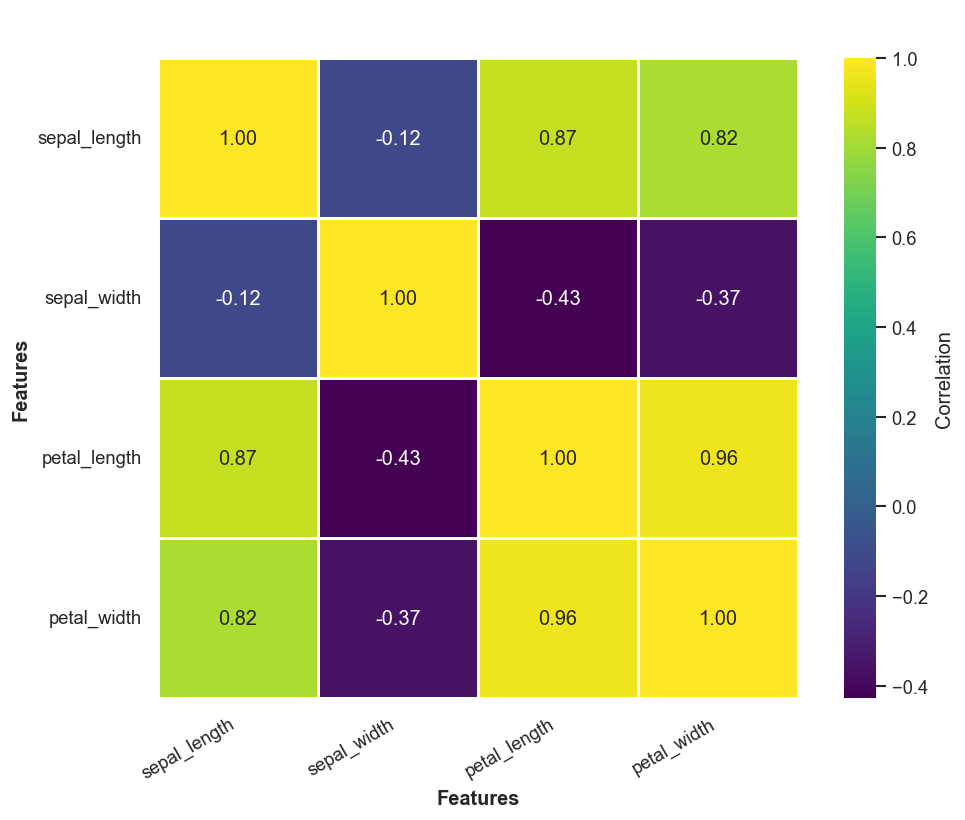

In [16]:
# ============================================================
# FEATURE CORRELATION HEATMAP
# ============================================================

correlation_matrix = df[feature_names].corr()

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.8,
    square=True,
    cbar_kws={
        "label": "Correlation"
    }
)

plt.title(
    "Correlation Between Iris Features",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Features",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Features",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Correlation Analysis

The correlation matrix shows the relationships between numerical
features.

Petal length and petal width generally show a strong positive
relationship, indicating that flowers with larger petals tend to
have both greater petal length and width.

# 🎯 5. Feature Selection Analysis

Feature selection helps identify which variables provide the
greatest predictive information.

Based on the exploratory visualizations:

- Petal length is highly discriminative.
- Petal width is highly discriminative.
- Sepal length provides useful information but has more overlap.
- Sepal width is comparatively less discriminative.

The pairplot and boxplots particularly demonstrate that petal
length and petal width provide strong separation between the
three species.

Therefore, all four features will initially be retained for model
training because each feature may contribute useful information.
The visual analysis will nevertheless be used to interpret the
relative importance of the features.

In [17]:
X = df[features]
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


### Why Standardization?

StandardScaler transforms numerical features so that they are
approximately centered around zero with a standard deviation of
one.

Scaling is particularly important for distance-based algorithms
such as K-Nearest Neighbors and can also improve Logistic
Regression optimization.

The scaler is fitted only on the training data to prevent
information leakage from the test set.

## 6. Model 1 — Logistic Regression

Logistic Regression is a strong baseline classification algorithm.
It is simple, interpretable, and effective for many classification
problems.

In [20]:
logistic_model = LogisticRegression(
    max_iter=200,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test_scaled
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy, 4))

print("Logistic Regression trained successfully.")

Logistic Regression Accuracy: 0.9333
Logistic Regression trained successfully.


## 7. Model 2 — K-Nearest Neighbors

K-Nearest Neighbors classifies an observation based on
the classes of nearby observations.

Feature scaling is important for KNN because the algorithm
uses distances between observations.

In [21]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_predictions = knn_model.predict(
    X_test_scaled
)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print("KNN Accuracy:",
      round(knn_accuracy, 4))

print("KNN trained successfully.")

KNN Accuracy: 0.9333
KNN trained successfully.


## 8. Model 3 — Random Forest

Random Forest is an ensemble learning algorithm that combines
multiple decision trees to improve predictive performance
and reduce overfitting.

Unlike KNN and Logistic Regression, Random Forest does not
require feature scaling.

In [22]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = random_forest_model.predict(
    X_test
)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Accuracy:",
      round(random_forest_accuracy, 4))

print("Random Forest trained successfully.")

Random Forest Accuracy: 0.9
Random Forest trained successfully.


In [23]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy,
        random_forest_accuracy
    ]
})

model_results = model_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

model_results

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbors,0.933333
2,Random Forest,0.900000


In [24]:
# ============================================================
# MODEL EVALUATION
# ============================================================

model_predictions = {
    "Logistic Regression": logistic_predictions,
    "K-Nearest Neighbors": knn_predictions,
    "Random Forest": random_forest_predictions
}

evaluation_results = []

for model_name, predictions in model_predictions.items():

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted"
        )
    })

evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_df = evaluation_df.round(4)

evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9333,0.9333,0.9333,0.9333
1,K-Nearest Neighbors,0.9333,0.9444,0.9333,0.9327
2,Random Forest,0.9000,0.9024,0.9000,0.8997


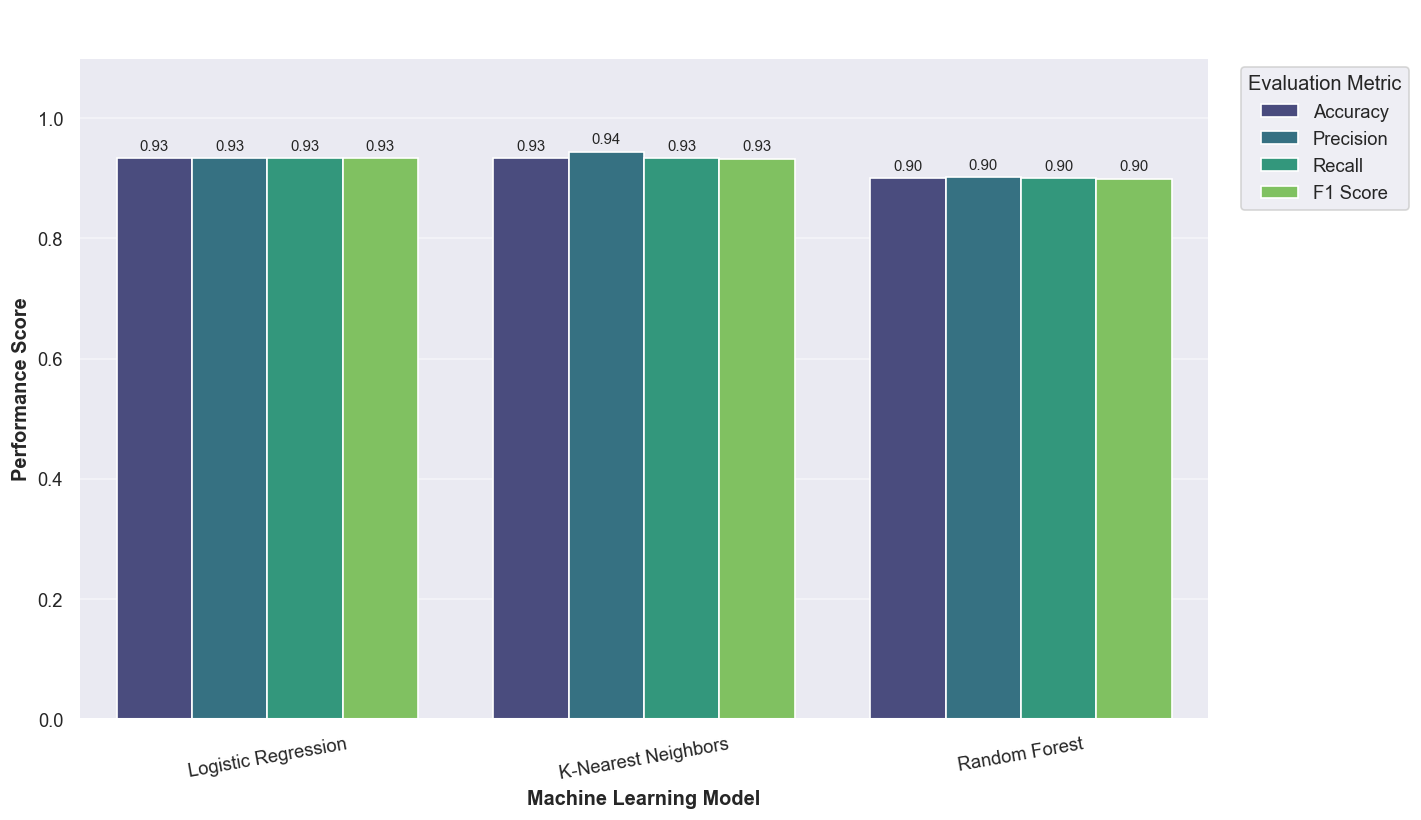

In [25]:
# ============================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================

evaluation_plot = evaluation_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(
    figsize=(12, 7)
)

ax = sns.barplot(
    data=evaluation_plot,
    x="Model",
    y="Score",
    hue="Metric",
    palette="viridis"
)

plt.title(
    "Machine Learning Model Performance Comparison",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Machine Learning Model",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Performance Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(
    0,
    1.10
)

plt.xticks(
    rotation=10
)

plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=9,
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
print("================== Logistic Regression ==================")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=iris.target_names
    )
)

print("================== K-Nearest Neighbors ==================")

print(
    classification_report(
        y_test,
        knn_predictions,
        target_names=iris.target_names
    )
)

print("==================== Random Forest ====================")

print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=iris.target_names
    )
)

================== Logistic Regression ==================
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

================== K-Nearest Neighbors ==================
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

==================== Random Forest ====================
              precision    recall  f1-score   support

      setos

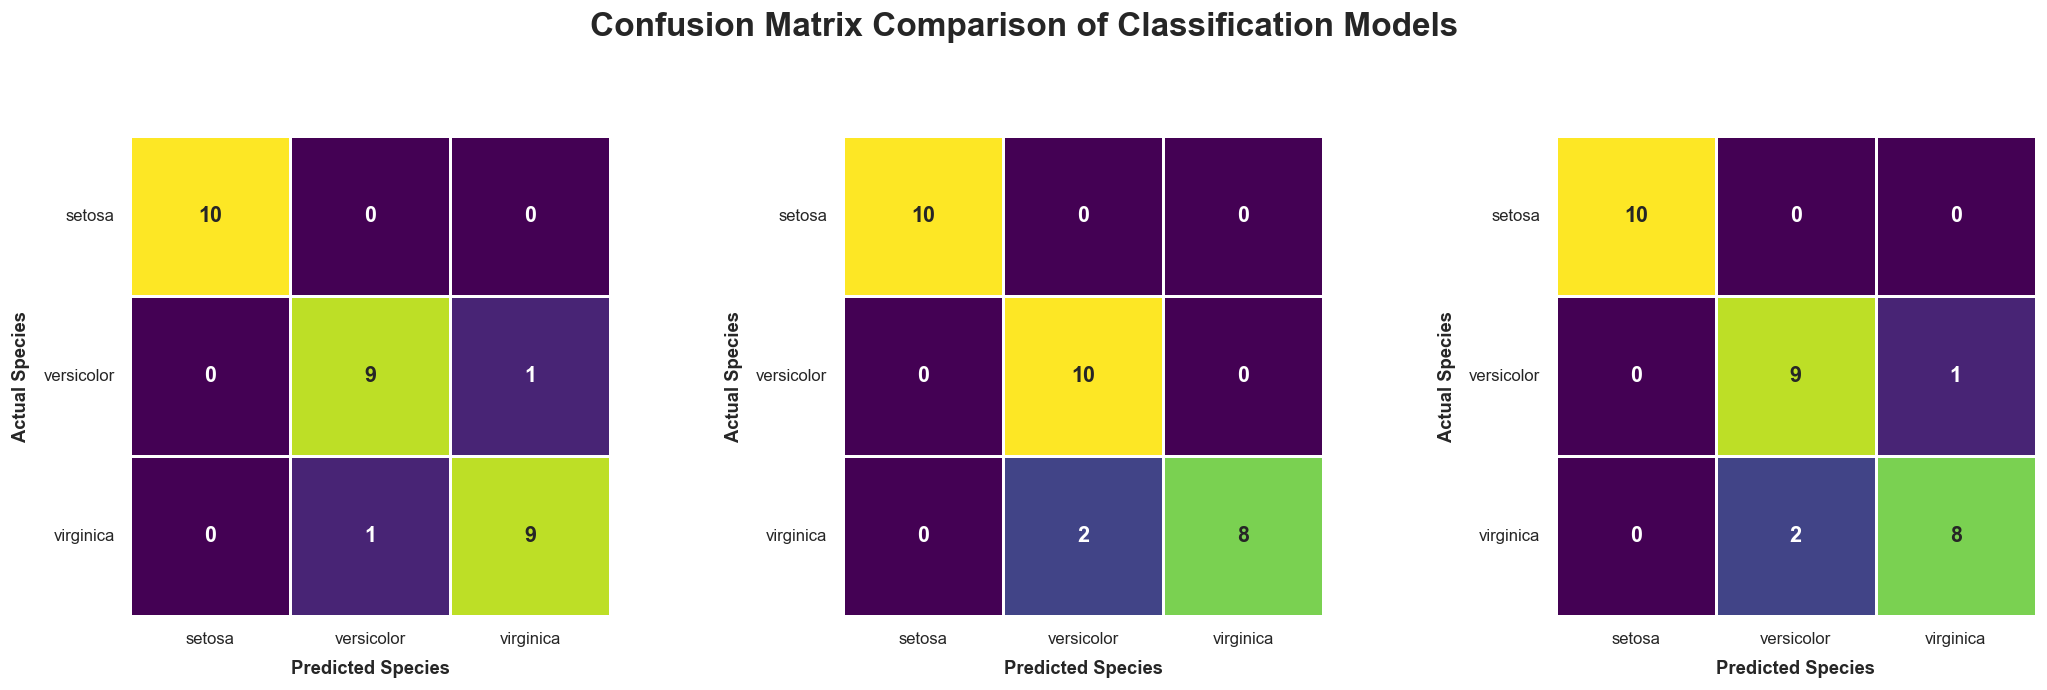

In [27]:
# ============================================================
# CONFUSION MATRIX COMPARISON
# ============================================================

# Dictionary containing predictions from all trained models
models_predictions = {
    "Logistic Regression": logistic_predictions,
    "K-Nearest Neighbors": knn_predictions,
    "Random Forest": random_forest_predictions
}


# Create a single figure containing all confusion matrices
fig, axes = plt.subplots(
    1,
    len(models_predictions),
    figsize=(18, 5.5)
)


# Generate confusion matrix for each model
for ax, (model_name, predictions) in zip(
    axes,
    models_predictions.items()
):

    # Calculate confusion matrix
    cm = confusion_matrix(
        y_test,
        predictions
    )

    # Plot confusion matrix
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="viridis",
        linewidths=0.8,
        square=True,
        cbar=False,
        xticklabels=iris.target_names,
        yticklabels=iris.target_names,
        annot_kws={
            "fontsize": 13,
            "fontweight": "bold"
        },
        ax=ax
    )

    # Chart title
    ax.set_title(
        model_name,
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    # Axis labels
    ax.set_xlabel(
        "Predicted Species",
        fontsize=11,
        fontweight="bold",
        labelpad=8
    )

    ax.set_ylabel(
        "Actual Species",
        fontsize=11,
        fontweight="bold",
        labelpad=8
    )

    # Tick labels
    ax.set_xticklabels(
        iris.target_names,
        rotation=0,
        fontsize=10
    )

    ax.set_yticklabels(
        iris.target_names,
        rotation=0,
        fontsize=10
    )


# Overall figure title
fig.suptitle(
    "Confusion Matrix Comparison of Classification Models",
    fontsize=20,
    fontweight="bold",
    y=1.03
)


# Improve spacing
plt.tight_layout()


# Save high-resolution image
plt.savefig(
    "../images/confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)


# Display figure
plt.show()

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = []

model_data = [
    ("Logistic Regression", logistic_predictions),
    ("K-Nearest Neighbors", knn_predictions),
    ("Random Forest", random_forest_predictions)
]

for model_name, predictions in model_data:

    comparison.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted"
        )
    })

comparison_df = pd.DataFrame(comparison)

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9333,0.9333,0.9333,0.9333
1,K-Nearest Neighbors,0.9333,0.9444,0.9333,0.9327
2,Random Forest,0.9000,0.9024,0.9000,0.8997


In [29]:
# ==========================================
# Save Model Comparison Results
# ==========================================

from pathlib import Path

# Get the project directory
project_dir = Path.cwd().parent

# Create outputs directory if it does not exist
outputs_dir = project_dir / "outputs"
outputs_dir.mkdir(exist_ok=True)

# Define output file path
output_file = outputs_dir / "model_comparison.csv"

# Save model comparison results
evaluation_df.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")
print(f"File location: {output_file}")

Model comparison saved successfully!
File location: c:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task1-IrisFlowerClassification\outputs\model_comparison.csv


In [30]:
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
3,petal_width,0.437185
2,petal_length,0.431466
0,sepal_length,0.116349
1,sepal_width,0.015000


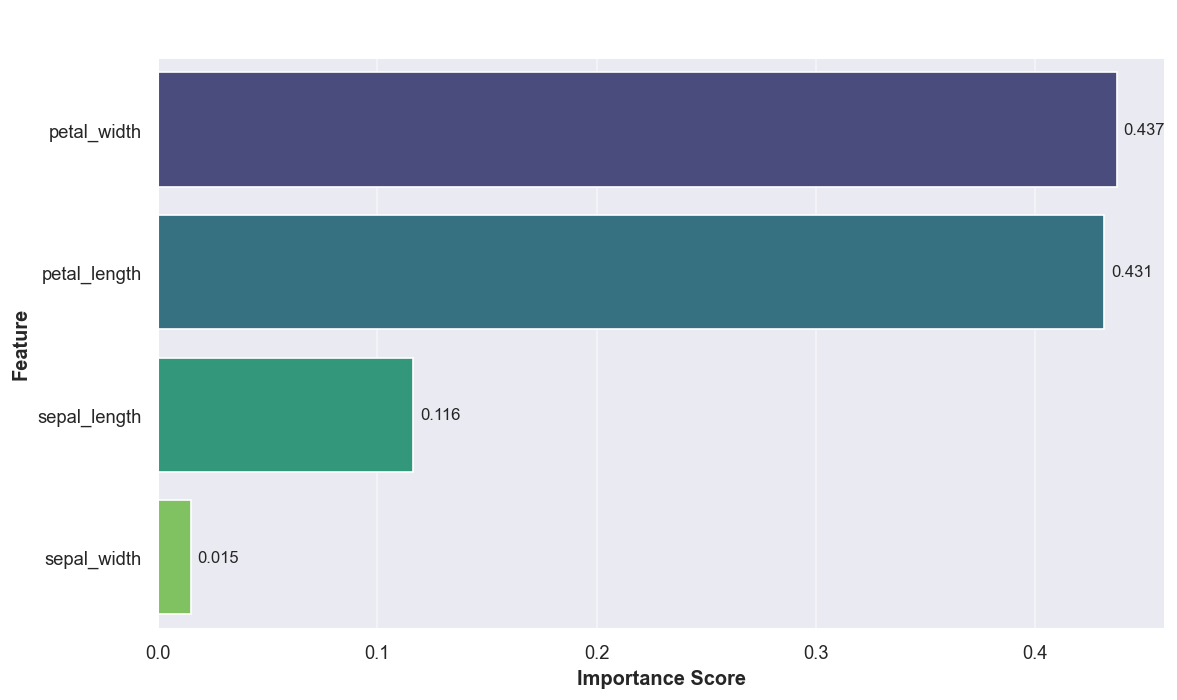

In [31]:
plt.figure(
    figsize=(10, 6)
)

ax = sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Importance Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Feature",
    fontsize=12,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=10,
        padding=4
    )

plt.tight_layout()

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# ============================================================
# BEST MODEL
# ============================================================

best_model_row = evaluation_df.loc[
    evaluation_df["F1 Score"].idxmax()
]

best_model_name = best_model_row["Model"]

print("Best Performing Model:", best_model_name)
print(
    "F1 Score:",
    round(best_model_row["F1 Score"], 4)
)

Best Performing Model: Logistic Regression
F1 Score: 0.9333


## 9. Best Model Selection

The best-performing model was selected based on its overall
classification performance, with particular attention to the
F1-score along with accuracy, precision, and recall.

The selected model provides the strongest balance between
correct predictions and consistent classification across
the three iris species.

In [33]:
# ============================================================
# SAMPLE PREDICTION
# ============================================================

sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=feature_names
)

sample_scaled = scaler.transform(sample)

sample_prediction = logistic_model.predict(
    sample_scaled
)

predicted_species = iris.target_names[
    sample_prediction[0]
]

print("Input measurements:")
print(sample)

print("\nPredicted Species:")
print(predicted_species.title())

Input measurements:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2

Predicted Species:
Setosa


# 🏆 10. Final Conclusion

The Iris Flower Classification project successfully demonstrated
a complete machine learning classification workflow.

### Key Findings

- The dataset contains 150 observations and four numerical features.
- No missing values were present in the dataset.
- The three target classes are Setosa, Versicolor, and Virginica.
- Petal length and petal width were identified as highly
  discriminative features.
- Three classification algorithms were evaluated:
  Logistic Regression, K-Nearest Neighbors, and Random Forest.
- The models were compared using accuracy, precision, recall,
  and F1-score.
- Confusion matrices were used to analyze classification errors.
- The best-performing model was selected based on its overall
  evaluation performance.

This project demonstrates the complete machine learning workflow
from exploratory data analysis through model development,
evaluation, interpretation, and prediction.